# 04 · 면역화와 Redington — 수학적 방패

[![Colab에서 열기](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/keerhee/pension-fund-strategy-and-performance/blob/main/W06_LDI%EC%99%80GBI/W06_M7_%EC%8B%A4%EC%8A%B5_Colab/04_%EB%A9%B4%EC%97%AD%ED%99%94_Redington.ipynb)

**W06 M7 LDI 강의본 단원 ④(37~44장)** 와 부록 B-3(80 · 81장)을 재현합니다.

| 단계 | 강의 | 이 노트북에서 |
|---|---|---|
| 잉여금 전개식 · 세 조건(금액 꼴) | 38 · 39장 | ΔS ≈ −(D_A·A − D_L·L)Δy + ½(C_A·A − C_L·L)Δy² · A = L · D_A·A = D_L·L · C_A·A > C_L·L |
| 1차 효과 | 40장 | 지금 기금 금리 −1%p: −(300 − 1,600) × (−0.01) = −13 |
| 바벨 검증 | 39 · 41 · 81장 | 부채 10년 뒤 100(PV 60.65) · 바벨 5년 38.94 + 15년 64.20(D 10 · C 125) vs 불일치 5년 77.88(D 5) · −2%p에서 +0.37 vs −7.05 · 금리별 표 |
| 증명 | 80장(B-3) | a ≠ 0이면 반례 · a = 0이면 b ≥ 0 · S ≥ 0 |
| 한계 | 44장 | 큰 충격(3차 이상 항) · 시간이 지나면 다시 맞춘다 · 비평행 이동 · 30·50년 국고채 437조 vs 순부채 2,122조 |

계산은 강의와 같이 **연속복리 y = 5%** 입니다.

### 0. 준비 — 이 셀부터 실행
한글 폰트(Colab은 나눔고딕 설치, 맥은 Pretendard), 강의 색(잉크 · 라임 · 티일 · 빨강), 강의본 숫자 확인 함수 `check()`를 준비합니다.
`check(이름, 계산값, 강의값, 허용오차)`는 계산이 강의본 숫자와 허용오차 안에서 맞는지 확인하고, 틀리면 멈춥니다(`assert`).
가정을 바꿔 실험할 때는 `FAST = True`로 두면 확인이 멈추지 않고 ✗로 표시만 합니다(M7 세트는 계산이 가벼워 속도 차이는 없음).

In [1]:
# ── 환경 준비: 한글 폰트 · 강의 색 · 확인 함수 (이 셀을 먼저 실행) ──
import sys, os, glob, math, time, subprocess
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import font_manager as fm

import warnings
warnings.filterwarnings("ignore", message=".*encountered in matmul")   # 맥 numpy(Accelerate)의 거짓 경고 — 결과와 무관
IN_COLAB = "google.colab" in sys.modules
if IN_COLAB and not glob.glob("/usr/share/fonts/truetype/nanum/NanumGothic*.ttf"):
    # Colab: 나눔 폰트 설치 (= !apt-get -qq install -y fonts-nanum) — 처음 한 번 10초 안팎
    subprocess.run("apt-get -qq install -y fonts-nanum > /dev/null", shell=True)

def setup_korean_font():
    """로컬 맥은 Pretendard, Colab은 나눔고딕을 matplotlib에 등록한다(폰트 캐시 갱신과 같은 효과)."""
    files = (glob.glob(os.path.expanduser("~/Library/Fonts/Pretendard-*.otf"))
             + glob.glob("/Library/Fonts/Pretendard-*.otf")
             + glob.glob("/usr/share/fonts/truetype/nanum/NanumGothic*.ttf"))
    for f in files:
        try:
            fm.fontManager.addfont(f)
        except Exception:
            pass
    names = {f.name for f in fm.fontManager.ttflist}
    for fam in ["Pretendard", "NanumGothic", "AppleGothic", "Malgun Gothic", "Noto Sans CJK KR"]:
        if fam in names:
            plt.rcParams["font.family"] = fam
            return fam
    return "(한글 폰트 없음 — 그래프 글자가 네모로 보이면 이 셀을 다시 실행)"

FONT = setup_korean_font()
plt.rcParams["axes.unicode_minus"] = False

# 강의 색 — 잉크 · 라임 · 티일 · 빨강 (+ 보조 회색 · 아이보리 바탕)
INK, LIME, TEAL, RED = "#071A1D", "#B7F34A", "#0B6B68", "#C00000"
GRAY, IVORY, OLIVE = "#8A9496", "#F7F5F0", "#5E8C1A"
plt.rcParams.update({
    "figure.figsize": (8, 4.5), "figure.dpi": 110, "savefig.dpi": 110,
    "figure.facecolor": "white", "axes.facecolor": IVORY,
    "axes.edgecolor": INK, "axes.labelcolor": INK, "xtick.color": INK, "ytick.color": INK,
    "axes.titleweight": "bold", "axes.titlesize": 13, "axes.titlelocation": "left",
    "axes.grid": True, "grid.color": "#DDD8CC", "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
    "legend.frameon": False, "axes.axisbelow": True,
    "axes.prop_cycle": matplotlib.cycler(color=[TEAL, INK, RED, OLIVE, GRAY]),
})

# 빠른 모드 — M7 세트는 계산이 가벼워 FAST가 결과를 바꾸지 않는다. True면 확인(check)이 멈추지 않고 표시만 한다(숫자를 바꿔 실험할 때)
FAST = False

CHECKS = []
def check(label, value, lecture, tol, fmt=".4f", unit=""):
    """계산값을 강의본 숫자와 비교한다. 기본(재현) 모드에서는 허용오차를 넘으면 멈춘다(assert)."""
    ok = abs(value - lecture) <= tol + 1e-9      # 허용오차는 보통 강의 표기 자릿수의 반(반올림하면 같은 값)
    CHECKS.append((label, ok))
    print(f"{'✓' if ok else '✗'} {label}: 계산 {value:{fmt}}{unit} · 강의 {lecture:{fmt}}{unit} (허용 ±{tol:g})")
    if not FAST:
        assert ok, f"{label}: 계산 {value} · 강의 {lecture}"

print(f"Colab: {IN_COLAB} · 그래프 폰트: {FONT} · numpy {np.__version__} · matplotlib {matplotlib.__version__}")

Colab: False · 그래프 폰트: Pretendard · numpy 2.0.2 · matplotlib 3.9.4


## 1. 잉여금 전개식과 세 조건 (강의 38 · 39장)
자산 · 부채를 각각 테일러 전개(03 노트북)해 빼면

**ΔS = ΔA − ΔL ≈ −(D_A·A − D_L·L)·Δy + ½·(C_A·A − C_L·L)·(Δy)²**

Redington(1952): 1차 항을 0으로, 2차 항을 양수로. 세 조건은 모두 **금액(×A, ×L) 꼴**입니다.

| 조건 | 식 | 막는 것 |
|---|---|---|
| 1 현재가치 일치 | A = L (실무: A ≥ L) | 출발선 부족 |
| 2 듀레이션 일치 | D_A·A = D_L·L | 1차 항(방향) |
| 3 볼록성 우위 | C_A·A > C_L·L | 2차 항(휘어짐) |

A = L일 때만 A · L이 약분되어 '자산 D = 부채 D · 자산 C > 부채 C'로 줄어듭니다.

In [2]:
def dS_approx(A, DA, CA, L, DL, CL, dy):
    """잉여금 변화의 2차 근사 — 첫 항(1차, 방향) + 둘째 항(2차, 휘어짐)"""
    first = -(DA * A - DL * L) * dy
    second = 0.5 * (CA * A - CL * L) * dy**2
    return first, second

# 강의 40장 — 지금 기금(A 100 · D_A 3, L 80 · D_L 20), 금리 −1%p, 1차 항만
first, _ = dS_approx(100, 3, 0, 80, 20, 0, -0.01)
print(f"자산 금액 듀레이션 {3 * 100} · 부채 금액 듀레이션 {20 * 80}")
print(f"첫 항 = −(300 − 1,600) × (−0.01) = {first:+.0f}  ← 03 노트북의 DV01 차이 −0.13 × 100bp와 같다")
check("지금 기금 1차 효과 (금리 −1%p)", first, -13, 0.5, ".1f")

자산 금액 듀레이션 300 · 부채 금액 듀레이션 1600
첫 항 = −(300 − 1,600) × (−0.01) = -13  ← 03 노트북의 DV01 차이 −0.13 × 100bp와 같다
✓ 지금 기금 1차 효과 (금리 −1%p): 계산 -13.0 · 강의 -13.0 (허용 ±0.5)


## 2. 바벨 검증 — 같은 PV 60.65의 두 자산 (강의 39 · 41 · 81장)
부채: 10년 뒤 100, y = 5% 연속복리 → L = 100·e^(−0.5) = 60.65, D_L = 10, C_L = 100.
- **바벨**: 5년물과 15년물에 현재가치를 반반(30.33씩) → 액면 5년 38.94 + 15년 64.20, D = 10, C = 10² + 5² = 125
- **불일치**: 5년물 하나에 전부 → 액면 77.88, D = 5 (조건 2 위반)

In [3]:
y0 = 0.05
L_face, L_t = 100.0, 10
def price(flows, y):
    """[(만기, 액면), ...]의 연속복리 현재가치"""
    return sum(f * np.exp(-y * t) for t, f in flows)

L0 = price([(L_t, L_face)], y0)
half = L0 / 2
barbell = [(5, half * np.exp(y0 * 5)), (15, half * np.exp(y0 * 15))]
mismatch = [(5, L0 * np.exp(y0 * 5))]

def dur_conv(flows, y):
    V = price(flows, y)
    D = sum(t * f * np.exp(-y * t) for t, f in flows) / V
    Cx = sum(t * t * f * np.exp(-y * t) for t, f in flows) / V
    return V, D, Cx

for name, fl in [("부채 10년 불릿", [(L_t, L_face)]), ("바벨 5 + 15년", barbell), ("불일치 5년", mismatch)]:
    V, D, Cx = dur_conv(fl, y0)
    print(f"{name:12s} 액면 {' + '.join(f'{t}년 {f:.2f}' for t, f in fl):24s} PV {V:.2f} · D {D:.1f} · C {Cx:.0f}")
check("부채 PV", L0, 60.65, 0.005, ".2f")
check("바벨 5년 액면", barbell[0][1], 38.94, 0.005, ".2f")
check("바벨 15년 액면", barbell[1][1], 64.20, 0.005, ".2f")
check("바벨 D", dur_conv(barbell, y0)[1], 10, 0.05, ".2f")
check("바벨 C", dur_conv(barbell, y0)[2], 125, 0.5, ".1f")
check("불일치 5년 액면", mismatch[0][1], 77.88, 0.005, ".2f")
check("불일치 D", dur_conv(mismatch, y0)[1], 5, 0.05, ".2f")

부채 10년 불릿    액면 10년 100.00               PV 60.65 · D 10.0 · C 100
바벨 5 + 15년   액면 5년 38.94 + 15년 64.20     PV 60.65 · D 10.0 · C 125
불일치 5년       액면 5년 77.88                 PV 60.65 · D 5.0 · C 25
✓ 부채 PV: 계산 60.65 · 강의 60.65 (허용 ±0.005)
✓ 바벨 5년 액면: 계산 38.94 · 강의 38.94 (허용 ±0.005)
✓ 바벨 15년 액면: 계산 64.20 · 강의 64.20 (허용 ±0.005)
✓ 바벨 D: 계산 10.00 · 강의 10.00 (허용 ±0.05)
✓ 바벨 C: 계산 125.0 · 강의 125.0 (허용 ±0.5)
✓ 불일치 5년 액면: 계산 77.88 · 강의 77.88 (허용 ±0.005)
✓ 불일치 D: 계산 5.00 · 강의 5.00 (허용 ±0.05)


**세 조건 확인.** 바벨은 조건 1 · 2 · 3을 모두 지키고, 불일치는 조건 2를 어깁니다.

In [4]:
for name, fl in [("바벨", barbell), ("불일치", mismatch)]:
    A, DA, CA = dur_conv(fl, y0)
    c1 = abs(A - L0) < 1e-9; c2 = abs(DA * A - 10 * L0) < 1e-6; c3 = CA * A > 100 * L0
    print(f"{name:4s} 조건 1 A = L: {'✓' if c1 else '✗'} · 조건 2 D_A·A = D_L·L ({DA * A:.1f} vs {10 * L0:.1f}): {'✓' if c2 else '✗'} · "
          f"조건 3 C_A·A > C_L·L ({CA * A:.0f} vs {100 * L0:.0f}): {'✓' if c3 else '✗'}")

바벨   조건 1 A = L: ✓ · 조건 2 D_A·A = D_L·L (606.5 vs 606.5): ✓ · 조건 3 C_A·A > C_L·L (7582 vs 6065): ✓
불일치  조건 1 A = L: ✓ · 조건 2 D_A·A = D_L·L (303.3 vs 606.5): ✗ · 조건 3 C_A·A > C_L·L (1516 vs 6065): ✗


**금리별 표 (강의 81장).** 금리가 평행 이동한 뒤 다시 할인해 잉여금 S = A − L(출발 0)을 구하고, 2차 근사 ΔS = ½ × 25 × 60.65 × Δy²와 비교합니다.

In [5]:
LECT = {-0.02: (74.08, 74.45, 0.37, 0.30, -7.05), -0.01: (67.03, 67.12, 0.08, 0.08, -3.27),
        +0.01: (54.88, 54.95, 0.07, 0.08, 2.81), +0.02: (49.66, 49.91, 0.25, 0.30, 5.22)}
print(f"{'Δy':>6s} {'부채 L':>8s} {'바벨 A':>8s} {'바벨 S':>8s} {'근사 ΔS':>8s} {'불일치 S':>9s}")
for dy, lec in LECT.items():
    Ld = price([(L_t, L_face)], y0 + dy); Ab = price(barbell, y0 + dy); Am = price(mismatch, y0 + dy)
    approx = 0.5 * (125 - 100) * L0 * dy**2
    row = (Ld, Ab, Ab - Ld, approx, Am - Ld)
    print(f"{dy * 100:+5.0f}%p {row[0]:8.2f} {row[1]:8.2f} {row[2]:+8.2f} {row[3]:+8.2f} {row[4]:+9.2f}")
    for lab, v, l in zip(["부채 L", "바벨 A", "바벨 S", "근사 ΔS", "불일치 S"], row, lec):
        check(f"Δy {dy * 100:+.0f}%p {lab}", v, l, 0.005, "+.2f")

    Δy     부채 L     바벨 A     바벨 S    근사 ΔS     불일치 S
   -2%p    74.08    74.45    +0.37    +0.30     -7.05
✓ Δy -2%p 부채 L: 계산 +74.08 · 강의 +74.08 (허용 ±0.005)
✓ Δy -2%p 바벨 A: 계산 +74.45 · 강의 +74.45 (허용 ±0.005)
✓ Δy -2%p 바벨 S: 계산 +0.37 · 강의 +0.37 (허용 ±0.005)
✓ Δy -2%p 근사 ΔS: 계산 +0.30 · 강의 +0.30 (허용 ±0.005)
✓ Δy -2%p 불일치 S: 계산 -7.05 · 강의 -7.05 (허용 ±0.005)
   -1%p    67.03    67.12    +0.08    +0.08     -3.27
✓ Δy -1%p 부채 L: 계산 +67.03 · 강의 +67.03 (허용 ±0.005)
✓ Δy -1%p 바벨 A: 계산 +67.12 · 강의 +67.12 (허용 ±0.005)
✓ Δy -1%p 바벨 S: 계산 +0.08 · 강의 +0.08 (허용 ±0.005)
✓ Δy -1%p 근사 ΔS: 계산 +0.08 · 강의 +0.08 (허용 ±0.005)
✓ Δy -1%p 불일치 S: 계산 -3.27 · 강의 -3.27 (허용 ±0.005)
   +1%p    54.88    54.95    +0.07    +0.08     +2.81
✓ Δy +1%p 부채 L: 계산 +54.88 · 강의 +54.88 (허용 ±0.005)
✓ Δy +1%p 바벨 A: 계산 +54.95 · 강의 +54.95 (허용 ±0.005)
✓ Δy +1%p 바벨 S: 계산 +0.07 · 강의 +0.07 (허용 ±0.005)
✓ Δy +1%p 근사 ΔS: 계산 +0.08 · 강의 +0.08 (허용 ±0.005)
✓ Δy +1%p 불일치 S: 계산 +2.81 · 강의 +2.81 (허용 ±0.005)
   +2%p    49.66    49.91    +0.25    +0.30    

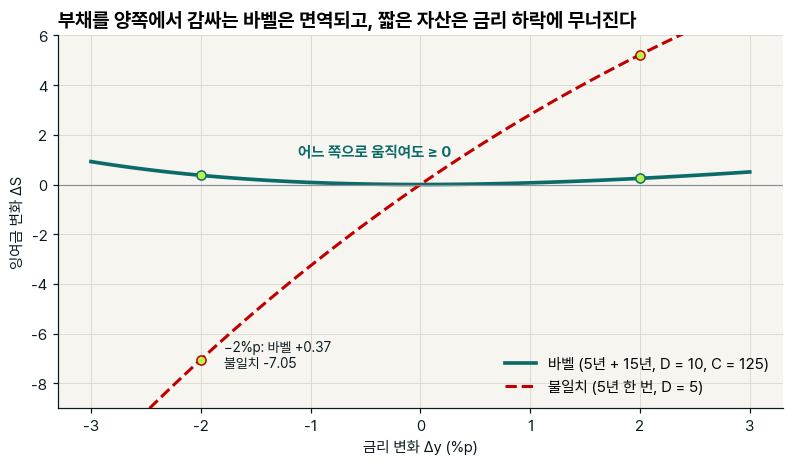

In [6]:
dys = np.linspace(-0.03, 0.03, 121)
Sb = np.array([price(barbell, y0 + d) - price([(L_t, L_face)], y0 + d) for d in dys])
Sm = np.array([price(mismatch, y0 + d) - price([(L_t, L_face)], y0 + d) for d in dys])
fig, ax = plt.subplots(figsize=(8.5, 4.4))
ax.plot(dys * 100, Sb, color=TEAL, lw=2.4, label="바벨 (5년 + 15년, D = 10, C = 125)")
ax.plot(dys * 100, Sm, color=RED, lw=2, ls="--", label="불일치 (5년 한 번, D = 5)")
ax.axhline(0, color=GRAY, lw=0.8)
ax.annotate("어느 쪽으로 움직여도 ≥ 0", (0, 0.05), textcoords="offset points", xytext=(-80, 18), color=TEAL, fontweight="bold")
for d in [-0.02, 0.02]:
    i = np.argmin(abs(dys - d))
    ax.scatter(d * 100, Sb[i], color=LIME, edgecolor=TEAL, zorder=5)
    ax.scatter(d * 100, Sm[i], color=LIME, edgecolor=RED, zorder=5)
ax.annotate(f"−2%p: 바벨 {Sb[np.argmin(abs(dys + 0.02))]:+.2f}\n불일치 {Sm[np.argmin(abs(dys + 0.02))]:+.2f}", (-2, Sm[np.argmin(abs(dys + 0.02))]),
            textcoords="offset points", xytext=(15, -5), fontsize=9, color=INK)
ax.set_ylim(-9, 6)
ax.set_xlabel("금리 변화 Δy (%p)"); ax.set_ylabel("잉여금 변화 ΔS")
ax.set_title("부채를 양쪽에서 감싸는 바벨은 면역되고, 짧은 자산은 금리 하락에 무너진다")
ax.legend(loc="lower right")
plt.show()

## 3. 부록 B-3 — 왜 세 조건인가 (강의 80장)
ΔS ≈ −a·Δy + ½·b·Δy², a = D_A·A − D_L·L, b = C_A·A − C_L·L.
- a ≠ 0이면 Δy가 작을 때 −a·Δy가 Δy²항을 이겨 **한쪽 방향에서 ΔS < 0** (반례). 불일치 자산은 a = (5 − 10) × 60.65 < 0 → 금리가 내리면 손실.
- a = 0이면 ΔS ≈ ½·b·Δy² → b ≥ 0이어야 어느 쪽에서도 손실이 없다.
- 출발점 S ≥ 0(A ≥ L)이면 S(y + Δy) = S + ΔS ≥ S ≥ 0 — 미분 언어로 S′(y) = 0, S″(y) ≥ 0, 골짜기 바닥.

아래에서 아주 작은 Δy(±1bp)로 반례를 확인합니다.

In [7]:
for name, fl in [("바벨", barbell), ("불일치", mismatch)]:
    A, DA, CA = dur_conv(fl, y0)
    a = round(DA * A - 10 * L0, 6) + 0.0; b = CA * A - 100 * L0
    s_dn = price(fl, y0 - 1e-4) - price([(L_t, L_face)], y0 - 1e-4)
    s_up = price(fl, y0 + 1e-4) - price([(L_t, L_face)], y0 + 1e-4)
    print(f"{name:4s} a = {a:+8.2f} · b = {b:+8.1f} · −1bp ΔS = {s_dn:+.5f} · +1bp ΔS = {s_up:+.5f}")

바벨   a =    +0.00 · b =  +1516.3 · −1bp ΔS = +0.00001 · +1bp ΔS = +0.00001
불일치  a =  -303.27 · b =  -4549.0 · −1bp ΔS = -0.03035 · +1bp ΔS = +0.03030


## 4. 면역화의 한계 (강의 44장)
| 한계 | 무엇이 문제인가 | 아래에서 |
|---|---|---|
| 큰 충격 | 테일러 근사의 3차 이상 항 | 표의 바벨 S(+0.37)와 근사(+0.30)의 차이 |
| 시간 · 금리 변화 | D · C가 변한다 → 다시 맞춘다 | 금리가 움직인 뒤 바벨 D가 10에서 벗어남 |
| 비평행 이동(비틀림) | 듀레이션 매칭은 평행 이동만 막는다 | 5년 · 15년 금리가 반대로 움직이면 바벨도 손실 |
| 공급 | 현금흐름 매칭할 장기채가 모자람 | 30 · 50년 국고채 437조 vs 순부채 2,122조 |

In [8]:
# (1) 금리가 움직인 뒤 듀레이션 — 다시 맞춰야 한다
for dy in [-0.02, 0.0, 0.02]:
    _, DA, _ = dur_conv(barbell, y0 + dy)
    print(f"금리 {dy * 100:+.0f}%p 뒤 바벨 D = {DA:.2f}년 (부채 D는 10년 그대로) → 갭 {DA - 10:+.2f}년")

# (2) 비평행 이동 — 10년을 축으로 비틀기: Δy(t) = k × (t − 10)  (교육용 예시, 강의 숫자 아님)
def S_twist(fl, k):
    A = sum(f * np.exp(-(y0 + k * (t - 10)) * t) for t, f in fl)
    return A - price([(L_t, L_face)], y0)
for k in [-0.001, 0.001]:
    print(f"비틀기 k = {k * 1e4:+.0f}bp/년 (5년 {-5 * k * 1e4:+.0f}bp · 15년 {5 * k * 1e4:+.0f}bp): 바벨 잉여금 {S_twist(barbell, k):+.2f}")

# (3) 공급 — 현금흐름 매칭으로 덮을 수 있는 몫
print(f"30 · 50년 국고채 잔액 437조 ÷ 국민연금 순부채 2,122조 = {437 / 2122:.0%} — 전부 사도 순부채의 5분의 1")

금리 -2%p 뒤 바벨 D = 10.50년 (부채 D는 10년 그대로) → 갭 +0.50년
금리 +0%p 뒤 바벨 D = 10.00년 (부채 D는 10년 그대로) → 갭 +0.00년
금리 +2%p 뒤 바벨 D = 9.50년 (부채 D는 10년 그대로) → 갭 -0.50년
비틀기 k = -10bp/년 (5년 +50bp · 15년 -50bp): 바벨 잉여금 +1.61
비틀기 k = +10bp/년 (5년 -50bp · 15년 +50bp): 바벨 잉여금 -1.42
30 · 50년 국고채 잔액 437조 ÷ 국민연금 순부채 2,122조 = 21% — 전부 사도 순부채의 5분의 1


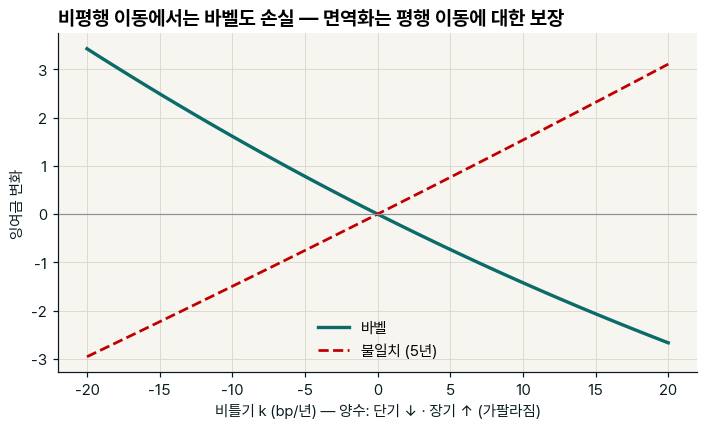

In [9]:
ks = np.linspace(-0.002, 0.002, 81)
fig, ax = plt.subplots(figsize=(7.5, 4))
ax.plot(ks * 1e4, [S_twist(barbell, k) for k in ks], color=TEAL, lw=2.2, label="바벨")
ax.plot(ks * 1e4, [S_twist(mismatch, k) for k in ks], color=RED, lw=1.8, ls="--", label="불일치 (5년)")
ax.axhline(0, color=GRAY, lw=0.8)
ax.set_xlabel("비틀기 k (bp/년) — 양수: 단기 ↓ · 장기 ↑ (가팔라짐)"); ax.set_ylabel("잉여금 변화")
ax.set_title("비평행 이동에서는 바벨도 손실 — 면역화는 평행 이동에 대한 보장")
ax.legend()
plt.show()

## 5. 정리
- 면역화 = 1차 항 0(금액 DV01 일치, h = 100%) + 2차 항 ≥ 0(금액 볼록성 우위).
- 평행 · 작은 이동에 대한 보장이며 계속 다시 맞춰야 합니다. 실무는 듀레이션 매칭 + 일부 초과수익 → 05 노트북의 두 블록.
- (TDF 글라이드패스 · 국면민감형 TDF(42 · 43장)는 계산 예제가 없는 개념 장이라 이 노트북에서는 다루지 않습니다.)

---
### 확인 결과 요약
이 노트북에서 강의본 숫자와 비교한 항목을 모아 봅니다. 모두 ✓이면 강의본 숫자를 그대로 재현한 것입니다.

In [10]:
# ── 확인 결과 요약 ──
n_ok = sum(ok for _, ok in CHECKS)
print(f"강의본 숫자 확인 {n_ok} / {len(CHECKS)} 통과" + (" — 빠른 모드라 일부 차이는 정상" if FAST else ""))
for label, ok in CHECKS:
    if not ok:
        print("  ✗", label)

강의본 숫자 확인 28 / 28 통과


---
## 바꿔 보기 (연습 문제)

1. 바벨을 3년물 + 17년물(현재가치 반반)로 바꾸면 D · C는? −2%p에서 잉여금은 5년 + 15년 바벨보다 큰가?
2. 부채가 A = 100 · L = 80(지금 기금)일 때 조건 2를 맞추려면 자산 D_A가 몇 년이어야 하나? (D_A·A = D_L·L)
3. `S_twist` 대신 5년 금리만 +1%p 오르고 15년 금리는 그대로인 경우를 직접 계산해 보라. 바벨과 불일치 중 누가 이기나?

아래 빈 셀에서 직접 해 보세요. 위 셀의 함수를 그대로 불러 쓰면 됩니다.

In [11]:
# 여기에 직접 해 보기

In [12]:
# 여기에 직접 해 보기

In [13]:
# 여기에 직접 해 보기